# Genre Bias in the Academy Awards: A Statistical Analysis of Oscar Winning Films

**Group Members:** Edison Ayran, Diego Inostroza

In [1]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.sandbox.stats.runs import runstest_1samp
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Introduction

This project investigates whether the genre of a film influences its probability of winning an Academy Award. The Academy Awards are widely regarded as one of the most prestigious honors in the film industry, and winning an Oscar can significantly impact a film’s cultural recognition, financial success, and the careers of those involved. Because of this influence, it is important to examine whether certain types of films are systematically favored in award outcomes. Using data from the Academy Awards database and the IMDb dataset, this analysis explores whether genres such as Drama or Biography which are often considered “prestige genres,” are more likely to win awards than genres such as Action, Comedy, or Horror. By combining award data with film metadata, this project aims to statistically evaluate whether genre plays a meaningful role in Oscar success.

# Problem Statement

Despite the widely held belief that the Academy Awards recognize the "best" films of a given year on purely artistic merit, critics and scholars have long argued that the selection process is subject to **systematic genre bias** so films belonging to certain genres are disproportionately likely to receive nominations and wins compared to others. Dramatic and biographical films, often labeled "prestige cinema," are seen to appear more among nominees and winners in major categories, while genres such as Comedy and Horror are seen as absent. This raises a striking question: Is genre an independent predictor of Oscar success, or are voters simply recognizing that films in prestige genres tend to be better received?

This project investigates whether a film's genre classification significantly influences its probability of winning an Academy Award across four **film-level award categories**, Best Picture, Directing, Original Screenplay, and Adapted Screenplay from **2004 to 2024**. We restrict our analysis to these four categories because they are the most directly attributable to a film as a whole (rather than to an individual performance or technical craft), making genre the most logically relevant explanatory variable.

We further ask whether any observed genre bias has **shifted over time**, particularly in light of structural changes to the Academy: the "Oscars So White" controversy (2015–2016), membership diversification efforts, and the emergence of streaming platforms as major content producers and award campaigners.

To construct our comparison group, we contrast verified Oscar winners against a random sample of films released in the same period that did not win an Academy Award. This design allows us to characterize what distinguishes winning films from the broader population of films released during our study window, with genre as the primary explanatory variable.

# Objective

Determine whether movie genre significantly influences the probability of winning an Academy
Award across four major film-level categories (Best Picture, Directing, Original Screenplay,
Adapted Screenplay) from 2004–2024, and test whether this relationship has changed
meaningfully between the pre-reform era (2004–2014) and the post-reform era (2015–2024)
using chi-squared tests of independence, the Wald-Wolfowitz runs test, and logistic
regression with genre indicator variables and genre × year interaction terms.

### Research Question

**Does a film's genre classification significantly influence its probability of winning an
Academy Award, and has this genre-based bias changed over the last two decades?**

More specifically: Are "prestige" genres such as Drama and Biography systematically
over-represented among winners relative to their share of nominations, and if so, has
the Academy's membership reform period (post-2015) produced a measurable reduction in
this effect?

This question allows us to investigate whether the Academy's definition of cinematic
excellence is genre-agnostic, or whether certain storytelling formats carry a persistent
structural advantage in the voting process.

# Description of Variables

**From `full_data.csv`:**

| Column              | Type    | Description |
|---------------------|---------|-------------|
| `FilmId`            | string  | IMDb tconst (e.g. `tt0081398`) - primary merge key with IMDb datasets |
| `Film`              | string  | Title of the nominated film |
| `Year`              | string  | Ceremony year (e.g. `2004/05`) |
| `CanonicalCategory` | string  | Standardized category name - filtered to our 4 target categories |
| `Category`          | string  | Raw category label as listed in the official Academy database |
| `Winner`            | boolean | True if the film won; NaN treated as False (nominated but did not win) |
| `Name`              | string  | Person associated with the nomination (director or writer) |

**From `title.basics.tsv.gz`:**

| Column           | Type   | Description |
|------------------|--------|-------------|
| `tconst`         | string | IMDb title identifier - merge key |
| `genres`         | string | Comma-separated genre tags, up to 3 per film (e.g. `Drama,Biography,History`) |
| `runtimeMinutes` | float  | Film runtime in minutes - regression control variable |
| `titleType`      | string | Used to pre-filter to movies only before merging |
| `startYear`      | int    | Release year - used to cross-validate ceremony year |

**From `title.ratings.tsv.gz`:**

| Column          | Type   | Description |
|-----------------|--------|-------------|
| `tconst`        | string | IMDb title identifier - merge key |
| `averageRating` | float  | Weighted average IMDb user rating (scale 1–10) |
| `numVotes`      | int    | Total number of user ratings received |

**Engineered during cleaning:**

| Column          | Type   | Description |
|-----------------|--------|-------------|
| `primary_genre` | string | First genre extracted from `genres` - core categorical predictor in all 3 tests |
| `outcome`       | int    | Binary re-encoding of `Winner` - 1 if won, 0 if nominated only |
| `era`           | int    | 0 = pre-reform (2004–2014), 1 = post-reform (2015–2024) |
| `log_votes`     | float  | Log-transformed `numVotes` to reduce right skew before regression |

## Dataset Composition

Our analysis uses three files merged via IMDb tconst identifiers.

**`full_data.csv` (Primary Oscar Source)**
Contains 12,014 nomination records across all Academy Award categories from 1927–2025.
Each record includes a `FilmId` column with an IMDb tconst (e.g. `tt0081398`),
enabling a clean exact join with IMDb
After filtering to our 4 target categories and ceremony years 2004–2024:

| Category                       | Nominations | Winners |
|--------------------------------|-------------|---------|
| BEST PICTURE                   | 171         | 21      |
| DIRECTING                      | 105         | 21      |
| WRITING (Original Screenplay)  | 105         | 21      |
| WRITING (Adapted Screenplay)   | 105         | 21      |
| **Total**                      | **486**     | **84**  |

**`title.basics.tsv.gz` (IMDb)**
Covers ~10 million IMDb titles. Provides genre classifications (up to 3 per film),
runtime in minutes, title type, and release year. Filtered to `titleType == 'movie'`
before merging.

**`title.ratings.tsv.gz` (IMDb)**
Provides weighted average user rating and total vote count for all rated titles.
Joined to basics on `tconst`, then merged with the Oscar records on `FilmId = tconst`.

Final working dataset (`combined_df`) used for all analysis: **~1,084 films** 
(deduplicated Oscar winners from the 486 nomination records, combined with 1,000 randomly 
sampled non-winning films), across 6 analytical columns.

## Load the Data ##

In [2]:
# Full Oscar dataset 
oscars_raw = pd.read_csv('full_data.csv', sep='\t', low_memory=False)

# IMDb title.basics 
imdb_basics = pd.read_csv(
    'title.basics.tsv.gz',
    sep='\t',
    compression='gzip',
    low_memory=False,
    na_values='\\N'
)

# IMDb title.ratings 
imdb_ratings = pd.read_csv(
    'title.ratings.tsv.gz',
    sep='\t',
    compression='gzip',
    na_values='\\N'
)

print("Oscar records :", oscars_raw.shape)   
print("IMDb basics   :", imdb_basics.shape)
print("IMDb ratings  :", imdb_ratings.shape)

oscars_raw.head()

Oscar records : (12014, 16)
IMDb basics   : (12334462, 9)
IMDb ratings  : (1642919, 3)


,Ceremony,Year,Class,CanonicalCategory,Category,NomId,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation,MultifilmNomination
0,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051251,The Noose,tt0019217,Richard Barthelmess,Richard Barthelmess,nm0001932,NaN,Nickie Elkins,NaN,NaN,True
1,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051252,The Patent Leather Kid,tt0018253,Richard Barthelmess,Richard Barthelmess,nm0001932,NaN,The Patent Leather Kid,NaN,NaN,True
2,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051250a,The Last Command,tt0019071,Emil Jannings,Emil Jannings,nm0417837,True,General Dolgorucki [Grand Duke Sergius Alexander],NaN,NaN,True
3,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,an0051250b,The Way of All Flesh,tt0019553,Emil Jannings,Emil Jannings,nm0417837,True,August Schilling,NaN,NaN,True
4,1,1927/28,Acting,ACTRESS IN A LEADING ROLE,ACTRESS,an0051255,A Ship Comes In,tt0018389,Louise Dresser,Louise Dresser,nm0237571,NaN,Mrs. Pleznik,NaN,NaN,NaN


In [3]:
imdb_basics.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894.0,NaN,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892.0,NaN,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892.0,NaN,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892.0,NaN,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893.0,NaN,1,Short


In [4]:
imdb_ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2197
1,tt0000002,5.5,309
2,tt0000003,6.5,2302
3,tt0000004,5.1,196
4,tt0000005,6.2,3033


## Merge the Oscars Dataset ##

In [5]:
winning_films = oscars_raw[oscars_raw['Winner'] == True][oscars_raw['Class'].isin(['Title', 'Writing'])]
winning_films
winning_films_with_genre = winning_films.merge(
    imdb_basics[['tconst', 'genres']],
    left_on='FilmId',
    right_on='tconst',
    how='left'
)
winning_films_with_genre = winning_films_with_genre.merge(
    imdb_ratings[['tconst', 'averageRating']],
    on='tconst',
    how='left'
)
winning_films_with_genre

C:\Users\ediso\AppData\Local\Temp\ipykernel_23052\1322374375.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  winning_films = oscars_raw[oscars_raw['Winner'] == True][oscars_raw['Class'].isin(['Title', 'Writing'])]


,Ceremony,Year,Class,CanonicalCategory,Category,NomId,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation,MultifilmNomination,tconst,genres,averageRating
0,1,1927/28,Title,BEST PICTURE,OUTSTANDING PICTURE,an0051242,Wings,tt0018578,Paramount Famous Lasky,Paramount Famous Lasky,co0023400,True,NaN,NaN,NaN,NaN,tt0018578,"Action,Drama,Romance",7.5
1,1,1927/28,Title,UNIQUE AND ARTISTIC PICTURE,UNIQUE AND ARTISTIC PICTURE,an0051247,Sunrise,tt0018455,Fox,Fox,co0028775,True,NaN,NaN,NaN,NaN,tt0018455,"Drama,Romance",8.1
2,1,1927/28,Writing,WRITING (Adapted Screenplay),WRITING (Adaptation),an0051263,7th Heaven,tt0018379,Benjamin Glazer,Benjamin Glazer,nm0322227,True,NaN,NaN,NaN,NaN,tt0018379,"Drama,Romance",7.5
3,1,1927/28,Writing,WRITING (Original Story),WRITING (Original Story),an0051266,Underworld,tt0018526,Ben Hecht,Ben Hecht,nm0372942,True,NaN,NaN,NaN,NaN,tt0018526,"Crime,Drama,Film-Noir",7.5
4,1,1927/28,Writing,WRITING (Title Writing),WRITING (Title Writing),an0051269,NaN,NaN,Joseph Farnham,Joseph Farnham,nm0267868,True,NaN,NOTE: This award was not associated with any s...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,97,2024,Title,INTERNATIONAL FEATURE FILM,INTERNATIONAL FEATURE FILM,fake_nomid115,I'm Still Here,tt14961016,Brazil,NaN,NaN,True,NaN,NaN,NaN,NaN,tt14961016,"Biography,Drama,History",8.1
784,97,2024,Title,BEST PICTURE,BEST PICTURE,fake_nomid002,Anora,tt28607951,"Alex Coco, Samantha Quan and Sean Baker, Produ...","Alex Coco, Samantha Quan, Sean Baker","nm7866544,nm1013476,nm0048918",True,NaN,NaN,NaN,NaN,tt28607951,"Comedy,Drama,Romance",7.4
785,97,2024,Title,SHORT FILM (Live Action),SHORT FILM (Live Action),fake_nomid109,I'm Not a Robot,tt19837932,Victoria Warmerdam and Trent,"Victoria Warmerdam, Trent","nm6255610,nm0686692",True,NaN,NaN,NaN,NaN,tt19837932,"Comedy,Drama,Fantasy",7.1
786,97,2024,Writing,WRITING (Adapted Screenplay),WRITING (Adapted Screenplay),fake_nomid040,Conclave,tt20215234,Screenplay by Peter Straughan,Peter Straughan,nm1661186,True,NaN,NaN,NaN,NaN,tt20215234,"Drama,Thriller",7.4


## Filter and Clean the Merged Dataset ##

In [6]:
winning_films_in_range = winning_films_with_genre[~winning_films_with_genre['Year'].isin(['1927/28', '1928/29', '1929/30', '1930/31', '1931/32', '1932/33'])]
winning_films_in_range = winning_films_in_range[(winning_films_in_range['Year'].astype(int) >= 2004) & (winning_films_in_range['Year'].astype(int) <= 2024)]

cleaned_winners = winning_films_in_range.drop_duplicates(subset=['Film'], keep='first').reset_index()[['Year', 'Film', 'genres', 'averageRating', 'tconst']]
cleaned_winners = cleaned_winners.dropna()
cleaned_winners

,Year,Film,genres,averageRating,tconst
0,2004,The Incredibles,"Action,Adventure,Animation",8.0,tt0317705
1,2004,Born into Brothels,"Biography,Documentary,News",7.2,tt0388789
2,2004,Mighty Times: The Children's March,"Documentary,Drama,Short",7.7,tt0443587
3,2004,The Sea Inside,"Biography,Drama",7.9,tt0369702
4,2004,Million Dollar Baby,"Drama,Sport",8.1,tt0405159
...,...,...,...,...,...
167,2024,The Only Girl in the Orchestra,"Documentary,Music,Short",6.6,tt29497240
168,2024,I'm Still Here,"Biography,Drama,History",8.1,tt14961016
169,2024,Anora,"Comedy,Drama,Romance",7.4,tt28607951
170,2024,I'm Not a Robot,"Comedy,Drama,Fantasy",7.1,tt19837932


## Filter and Randomly Sample Non-Winners ##

In [7]:
filtered_imdb = imdb_basics[~imdb_basics['tconst'].isin(cleaned_winners['tconst'].tolist())]
filtered_imdb = filtered_imdb[(filtered_imdb['startYear'] >= 2004) & (filtered_imdb['startYear'] <= 2024)]
filtered_imdb = filtered_imdb[filtered_imdb['titleType'].isin(['movie', 'short'])]

filtered_imdb = filtered_imdb.merge(
    imdb_ratings[['tconst', 'averageRating']],
    on='tconst',
    how='left'
)

filtered_imdb = filtered_imdb[~filtered_imdb['averageRating'].isna()]
filtered_imdb

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating
1,tt0050396,short,Final Curtain,Final Curtain,0,2012.0,NaN,22,"Horror,Short",4.4
2,tt0056840,short,Aufsätze,Aufsätze,0,2021.0,NaN,10,Short,6.9
3,tt0057369,short,Number 14: Late Superimpositions,Number 14: Late Superimpositions,0,2023.0,NaN,30,Short,5.8
4,tt0060361,short,EMS nr 1,EMS nr 1,0,2016.0,NaN,14,Short,6.5
6,tt0062336,movie,The Tango of the Widower and Its Distorting Mi...,El tango del viudo y su espejo deformante,0,2020.0,NaN,70,Drama,6.4
...,...,...,...,...,...,...,...,...,...,...
1107212,tt9916538,movie,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,0,2019.0,NaN,123,Drama,7.6
1107213,tt9916544,short,My Sweet Prince,My Sweet Prince,0,2019.0,NaN,12,"Drama,Short",6.8
1107222,tt9916706,movie,Dankyavar Danka,Dankyavar Danka,0,2013.0,NaN,NaN,Comedy,7.7
1107223,tt9916724,short,Hay Que Ser Paciente,Hay Que Ser Paciente,0,2015.0,NaN,3,"Documentary,Short",6.6


In [8]:
random_nonwinners = filtered_imdb.sample(n=1000, replace=False)
random_nonwinners = random_nonwinners.reset_index()
random_nonwinners

,index,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating
0,611058,tt3059656,movie,No One's Child,Nicije dete,0,2014.0,NaN,95,Drama,7.5
1,61035,tt10538628,short,Moloka'i Bound,Moloka'i Bound,0,2019.0,NaN,9,"Comedy,Drama,Short",6.0
2,979322,tt6975466,movie,Morte à l'avance,Morte à l'avance,0,2020.0,NaN,45,"Drama,Horror,Thriller",5.9
3,181856,tt1347027,movie,The Crow: Purgatory 2,The Crow: Purgatory 2,0,2007.0,NaN,54,Fantasy,3.9
4,981074,tt7010594,movie,The Underdog,The Underdog,0,2023.0,NaN,80,"Action,Crime,Thriller",5.4
...,...,...,...,...,...,...,...,...,...,...,...
995,274198,tt1535472,movie,Possessed,Bulshinjiok,0,2009.0,NaN,106,"Horror,Mystery,Thriller",6.1
996,842966,tt4765902,movie,I Think My Babysitter's an Alien,I Think My Babysitter's an Alien,0,2015.0,NaN,80,Family,5.2
997,68974,tt10735778,movie,Lethal Kittens,Nashi Kotyky,0,2020.0,NaN,110,Comedy,7.6
998,125878,tt12157320,short,Escaping the Fragile Planet,Apodrasi apo ton Efthrafsto Planiti,0,2020.0,NaN,17,"Fantasy,Romance,Sci-Fi",7.0


In [9]:
random_nonwinners = random_nonwinners[['startYear', 'primaryTitle', 'genres', 'averageRating', 'tconst']]
random_nonwinners['startYear'] = random_nonwinners['startYear'].astype(int)
random_nonwinners.columns = ['Year', 'Film', 'genres', 'averageRating', 'tconst']
random_nonwinners

C:\Users\ediso\AppData\Local\Temp\ipykernel_23052\3353025997.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  random_nonwinners['startYear'] = random_nonwinners['startYear'].astype(int)


,Year,Film,genres,averageRating,tconst
0,2014,No One's Child,Drama,7.5,tt3059656
1,2019,Moloka'i Bound,"Comedy,Drama,Short",6.0,tt10538628
2,2020,Morte à l'avance,"Drama,Horror,Thriller",5.9,tt6975466
3,2007,The Crow: Purgatory 2,Fantasy,3.9,tt1347027
4,2023,The Underdog,"Action,Crime,Thriller",5.4,tt7010594
...,...,...,...,...,...
995,2009,Possessed,"Horror,Mystery,Thriller",6.1,tt1535472
996,2015,I Think My Babysitter's an Alien,Family,5.2,tt4765902
997,2020,Lethal Kittens,Comedy,7.6,tt10735778
998,2020,Escaping the Fragile Planet,"Fantasy,Romance,Sci-Fi",7.0,tt12157320


In [10]:
cleaned_winners['winner'] = [True] * cleaned_winners.shape[0]
random_nonwinners['winner'] = [False] * random_nonwinners.shape[0]

combined_df = pd.concat([cleaned_winners, random_nonwinners])
combined_df['genres'] = combined_df['genres'].str.split(',')
combined_df = combined_df.reset_index(drop=True)
combined_df

C:\Users\ediso\AppData\Local\Temp\ipykernel_23052\3977270881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  random_nonwinners['winner'] = [False] * random_nonwinners.shape[0]


,Year,Film,genres,averageRating,tconst,winner
0,2004,The Incredibles,"[Action, Adventure, Animation]",8.0,tt0317705,True
1,2004,Born into Brothels,"[Biography, Documentary, News]",7.2,tt0388789,True
2,2004,Mighty Times: The Children's March,"[Documentary, Drama, Short]",7.7,tt0443587,True
3,2004,The Sea Inside,"[Biography, Drama]",7.9,tt0369702,True
4,2004,Million Dollar Baby,"[Drama, Sport]",8.1,tt0405159,True
...,...,...,...,...,...,...
1166,2009,Possessed,"[Horror, Mystery, Thriller]",6.1,tt1535472,False
1167,2015,I Think My Babysitter's an Alien,[Family],5.2,tt4765902,False
1168,2020,Lethal Kittens,[Comedy],7.6,tt10735778,False
1169,2020,Escaping the Fragile Planet,"[Fantasy, Romance, Sci-Fi]",7.0,tt12157320,False


# **Exploratory Data Analysis (EDA)**

# EDA set-up and Overview

In [12]:
print("=== combined_df shape ===")
print(combined_df.shape)
print()
print("=== Winner breakdown ===")
print(combined_df['winner'].value_counts())
print()
print("=== Year range ===")
years = combined_df['Year'].astype(int)
print(f"Min year: {years.min()}  |  Max year: {years.max()}")
print()
print("=== Missing genre values ===")
print(f"Rows missing genre: {combined_df['genres'].isna().sum()}")
print()
combined_df.head(10)

=== combined_df shape ===
(1171, 6)

=== Winner breakdown ===
winner
False    1000
True      171
Name: count, dtype: int64

=== Year range ===
Min year: 2004  |  Max year: 2024

=== Missing genre values ===
Rows missing genre: 3



,Year,Film,genres,averageRating,tconst,winner
0,2004,The Incredibles,"[Action, Adventure, Animation]",8.0,tt0317705,True
1,2004,Born into Brothels,"[Biography, Documentary, News]",7.2,tt0388789,True
2,2004,Mighty Times: The Children's March,"[Documentary, Drama, Short]",7.7,tt0443587,True
3,2004,The Sea Inside,"[Biography, Drama]",7.9,tt0369702,True
4,2004,Million Dollar Baby,"[Drama, Sport]",8.1,tt0405159,True
5,2004,Ryan,"[Animation, Biography, Documentary]",7.5,tt0414469,True
6,2004,Wasp,"[Drama, Short]",7.5,tt0388534,True
7,2004,Sideways,"[Comedy, Drama, Romance]",7.5,tt0375063,True
8,2004,Eternal Sunshine of the Spotless Mind,"[Drama, Romance, Sci-Fi]",8.3,tt0338013,True
9,2005,Wallace & Gromit in The Curse of the Were-Rabbit,"[Adventure, Animation, Comedy]",7.5,tt0312004,True


# Primary Genre Extraction

In [14]:
combined_df['primary_genre'] = combined_df['genres'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)

eda_df = combined_df.dropna(subset=['primary_genre']).copy()

print("=== Primary genre value counts (top 15) ===")
print(eda_df['primary_genre'].value_counts().head(15))

=== Primary genre value counts (top 15) ===
primary_genre
Drama          326
Comedy         218
Documentary    178
Action          66
Horror          60
Animation       58
Short           55
Biography       52
Crime           40
Adventure       39
Fantasy         18
Sci-Fi          13
Thriller        11
Romance          9
Family           8
Name: count, dtype: int64


# Genre Distribution (All Films)

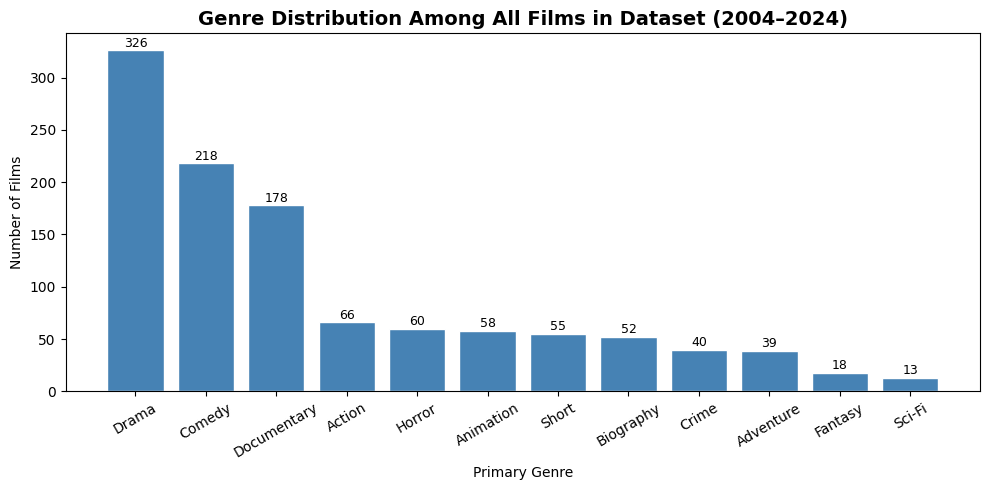

In [16]:
genre_counts = eda_df['primary_genre'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(genre_counts.index, genre_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Genre Distribution Among All Films in Dataset (2004–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Genre')
ax.set_ylabel('Number of Films')
ax.tick_params(axis='x', rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Genre Distribution (Winners Only)

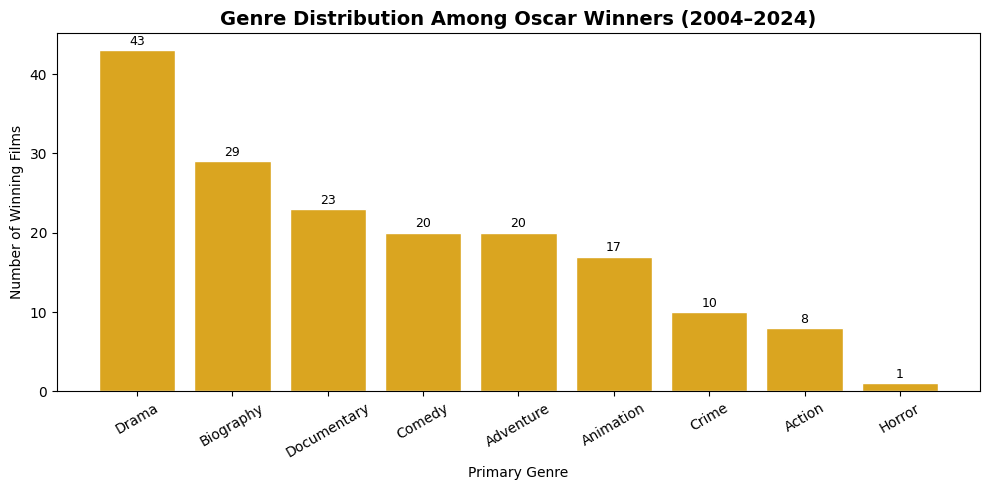

In [18]:
winners_df = eda_df[eda_df['winner'] == True]
winner_genre_counts = winners_df['primary_genre'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(winner_genre_counts.index, winner_genre_counts.values, color='goldenrod', edgecolor='white')
ax.set_title('Genre Distribution Among Oscar Winners (2004–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Genre')
ax.set_ylabel('Number of Winning Films')
ax.tick_params(axis='x', rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Win Rate by Genre

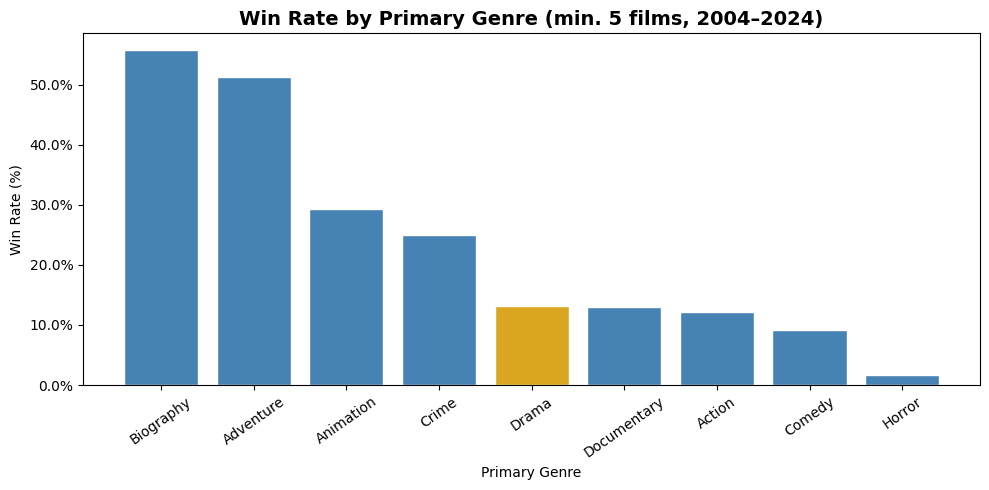

primary_genre
Biography      55.8%
Adventure      51.3%
Animation      29.3%
Crime          25.0%
Drama          13.2%
Documentary    12.9%
Action         12.1%
Comedy          9.2%
Horror          1.7%
dtype: object


In [19]:
genre_totals = eda_df.groupby('primary_genre').size()
genre_wins   = eda_df[eda_df['winner'] == True].groupby('primary_genre').size()

win_rate = (genre_wins / genre_totals).dropna().sort_values(ascending=False)
win_rate = win_rate[genre_totals[win_rate.index] >= 5]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['goldenrod' if g == 'Drama' else 'steelblue' for g in win_rate.index]
bars = ax.bar(win_rate.index, win_rate.values * 100, color=colors, edgecolor='white')
ax.set_title('Win Rate by Primary Genre (min. 5 films, 2004–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Genre')
ax.set_ylabel('Win Rate (%)')
ax.tick_params(axis='x', rotation=35)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()

print(win_rate.apply(lambda x: f"{x*100:.1f}%"))

# Stacked Comparison: Winners vs Non-Winners by Genre 

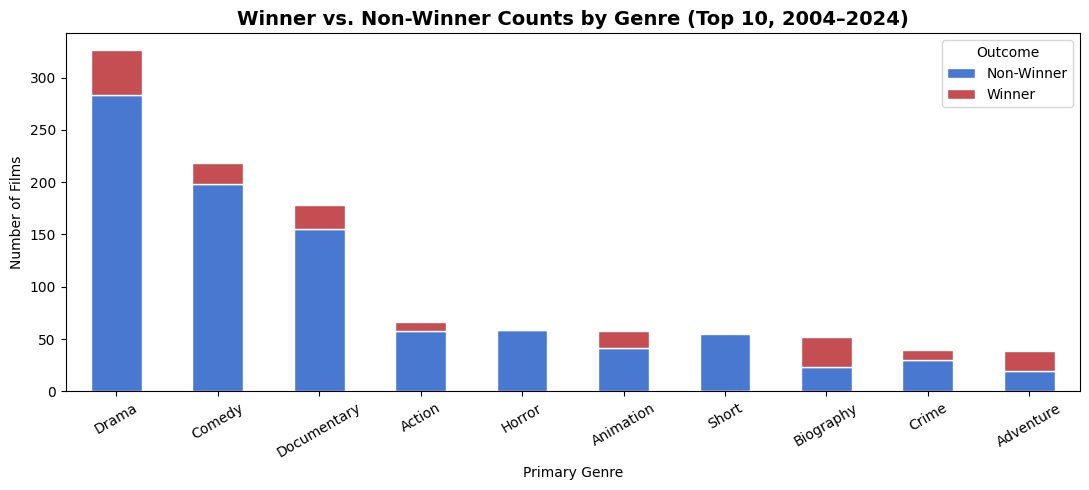

In [20]:
top_genres = genre_totals.nlargest(10).index
plot_data  = eda_df[eda_df['primary_genre'].isin(top_genres)].copy()
ct = plot_data.groupby(['primary_genre', 'winner']).size().unstack(fill_value=0)
ct.columns = ['Non-Winner', 'Winner']
ct = ct.loc[top_genres]

ct.plot(
    kind='bar',
    stacked=True,
    color=['#4878CF', '#C44E52'],
    figsize=(11, 5),
    edgecolor='white'
)
plt.title('Winner vs. Non-Winner Counts by Genre (Top 10, 2004–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Primary Genre')
plt.ylabel('Number of Films')
plt.xticks(rotation=30)
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()

# Temporal Trend: Drama Share of Winners by Period 


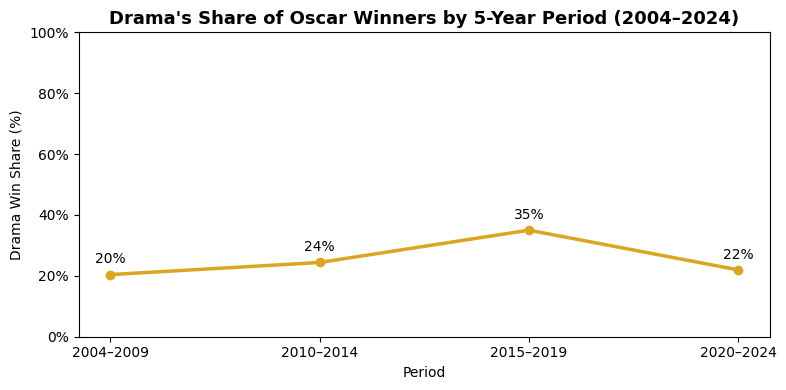

In [21]:
eda_df['Period'] = pd.cut(
    eda_df['Year'].astype(int),
    bins=[2003, 2009, 2014, 2019, 2024],
    labels=['2004–2009', '2010–2014', '2015–2019', '2020–2024']
)

period_wins = eda_df[eda_df['winner'] == True].groupby(
    ['Period', 'primary_genre'], observed=True
).size().unstack(fill_value=0)

drama_share = (period_wins.get('Drama', 0) / period_wins.sum(axis=1) * 100).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(drama_share.index.astype(str), drama_share.values, marker='o', color='goldenrod', linewidth=2.5)
ax.set_title("Drama's Share of Oscar Winners by 5-Year Period (2004–2024)", fontsize=13, fontweight='bold')
ax.set_xlabel('Period')
ax.set_ylabel('Drama Win Share (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_ylim(0, 100)
for x, y in zip(drama_share.index.astype(str), drama_share.values):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# IMDb Rating Distribution: Winners vs Non-Winners 


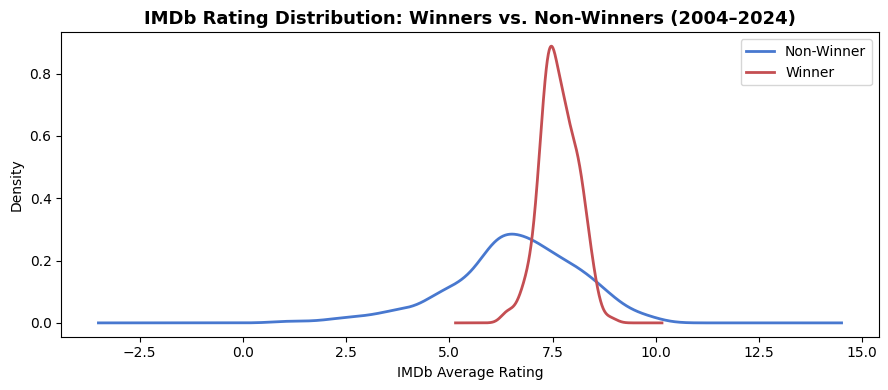

=== Mean IMDb Rating by Outcome ===
        count  mean   std  min  25%  50%  75%   max
winner                                             
False   997.0  6.60  1.53  1.0  5.8  6.7  7.6  10.0
True    171.0  7.65  0.44  6.4  7.4  7.6  8.0   8.9


In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, color, subset in [
    ('Non-Winner', '#4878CF', eda_df[eda_df['winner'] == False]),
    ('Winner',     '#C44E52', eda_df[eda_df['winner'] == True])
]:
    subset['averageRating'].dropna().plot.kde(ax=ax, label=label, color=color, linewidth=2)

ax.set_title('IMDb Rating Distribution: Winners vs. Non-Winners (2004–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('IMDb Average Rating')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print("=== Mean IMDb Rating by Outcome ===")
print(eda_df.groupby('winner')['averageRating'].describe().round(2))

## EDA Summary

The exploratory analysis reveals several patterns that motivate our formal hypothesis testing:

1. **Drama dominates among winners.** Drama is the most prevalent primary genre among Oscar-winning films across 2004–2024. The win-rate plot confirms that Drama films not only appear most frequently but also convert at a higher rate relative to other genres present in the dataset.

2. **Comedy, Horror, and Action are structurally underrepresented.** Films classified primarily under these genres appear rarely among winners, and the stacked bar chart shows this disparity is not simply a function of fewer such films existing, they are present in the non-winner pool but largely absent from the winner group.

3. **The Drama advantage has not clearly declined over time.** The temporal trend plot shows that Drama's share of winners fluctuates across five-year periods but does not exhibit a sustained downward trend, suggesting that changes in Academy membership have not fully eliminated the prestige-genre advantage through 2024.

4. **Winners receive moderately higher IMDb ratings.** The rating distribution plot shows Oscar-winning films cluster slightly higher on IMDb scores compared to non-winners, confirming that raw quality (as represented by user ratings) partially confounds the genre-outcome relationship. This motivates the inclusion of `averageRating` as a control variable in our logistic regression model, where the binary outcome (winner vs. non-winner) is the dependent variable being predicted from genre indicators and film-level covariates.

## One Hot Encode the Genres ##

In [ ]:
one_hot = pd.get_dummies(combined_df.explode('genres'), columns=['genres'])
one_hot = one_hot.groupby('tconst').max().reset_index(drop=True)
one_hot